In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [21]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

In [22]:
def vectorize_sequences(sequences, dimensions = 10000):
  results = np.zeros((len(sequences), dimensions))
  for i,sequences in enumerate(sequences):
    results[i, sequences] = 1
  return results

X_train = vectorize_sequences(X_train)
X_test = vectorize_sequences(X_test)


In [23]:
y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_test).astype('float32')

In [5]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (25000, 200)
X_test Shape: (25000, 200)


In [28]:
model = Sequential()

# First hidden layer
model.add(Dense(128, activation='relu', input_shape=(10000,)))

# Second hidden layer
model.add(Dense(64, activation='relu'))

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# Step 9: Compile the model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
# Step 10: Display model summary

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,449 (4.92 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Step 11: Train the model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.8607 - loss: 0.3383 - val_accuracy: 0.8868 - val_loss: 0.2838
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9373 - loss: 0.1663 - val_accuracy: 0.8834 - val_loss: 0.3115
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9632 - loss: 0.0994 - val_accuracy: 0.8776 - val_loss: 0.3858
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9847 - loss: 0.0428 - val_accuracy: 0.8734 - val_loss: 0.5112
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9973 - loss: 0.0112 - val_accuracy: 0.8762 - val_loss: 0.6096
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9998 - loss: 0.0019 - val_accuracy: 0.8748 - val_loss: 0.7469
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9999 - loss: 5.0836e-04 - val_accuracy: 0.8732 - val_loss: 0.8147
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 1.0000 - loss: 2.6820e-04 

In [32]:
# Step 12: Evaluate model performance

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8616 - loss: 1.0437
Test Loss: 1.0437209606170654
Test Accuracy: 0.8616399765014648


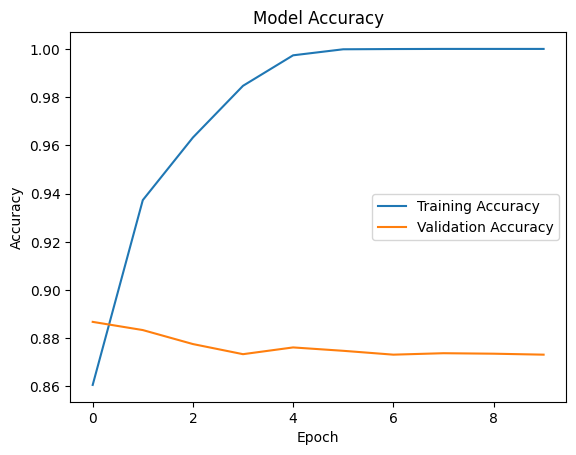

In [33]:
# Step 17: Plot training and validation accuracy

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

In [34]:
# =========================
# 11. FINAL ACCURACY
# =========================
loss, accuracy = model.evaluate(X_test, y_test)
print("\nFinal Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8616 - loss: 1.0437

Final Accuracy: 0.8616399765014648
